# 1. Understanding Data

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [3]:
df = pd.read_csv('data/Train.csv')
df_Test = pd.read_csv('data/Train.csv')

In [5]:
df.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(30557, 82)

In [7]:
df.nunique()

Place_ID X Date                 30557
Date                               94
Place_ID                          340
target                            375
target_min                        269
                                ...  
L3_CH4_aerosol_optical_depth     2874
L3_CH4_sensor_azimuth_angle      2874
L3_CH4_sensor_zenith_angle       2874
L3_CH4_solar_azimuth_angle       2874
L3_CH4_solar_zenith_angle        2874
Length: 82, dtype: int64

In [8]:
df.columns.unique()


Index(['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min',
       'target_max', 'target_variance', 'target_count',
       'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
   

In [9]:
list(df.columns)

['Place_ID X Date',
 'Date',
 'Place_ID',
 'target',
 'target_min',
 'target_max',
 'target_variance',
 'target_count',
 'precipitable_water_entire_atmosphere',
 'relative_humidity_2m_above_ground',
 'specific_humidity_2m_above_ground',
 'temperature_2m_above_ground',
 'u_component_of_wind_10m_above_ground',
 'v_component_of_wind_10m_above_ground',
 'L3_NO2_NO2_column_number_density',
 'L3_NO2_NO2_slant_column_number_density',
 'L3_NO2_absorbing_aerosol_index',
 'L3_NO2_cloud_fraction',
 'L3_NO2_sensor_altitude',
 'L3_NO2_sensor_azimuth_angle',
 'L3_NO2_sensor_zenith_angle',
 'L3_NO2_solar_azimuth_angle',
 'L3_NO2_solar_zenith_angle',
 'L3_NO2_stratospheric_NO2_column_number_density',
 'L3_NO2_tropopause_pressure',
 'L3_NO2_tropospheric_NO2_column_number_density',
 'L3_O3_O3_column_number_density',
 'L3_O3_O3_effective_temperature',
 'L3_O3_cloud_fraction',
 'L3_O3_sensor_azimuth_angle',
 'L3_O3_sensor_zenith_angle',
 'L3_O3_solar_azimuth_angle',
 'L3_O3_solar_zenith_angle',
 'L3_CO_CO

In [10]:
df.columns[df.columns.duplicated()]


Index([], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

<Axes: >

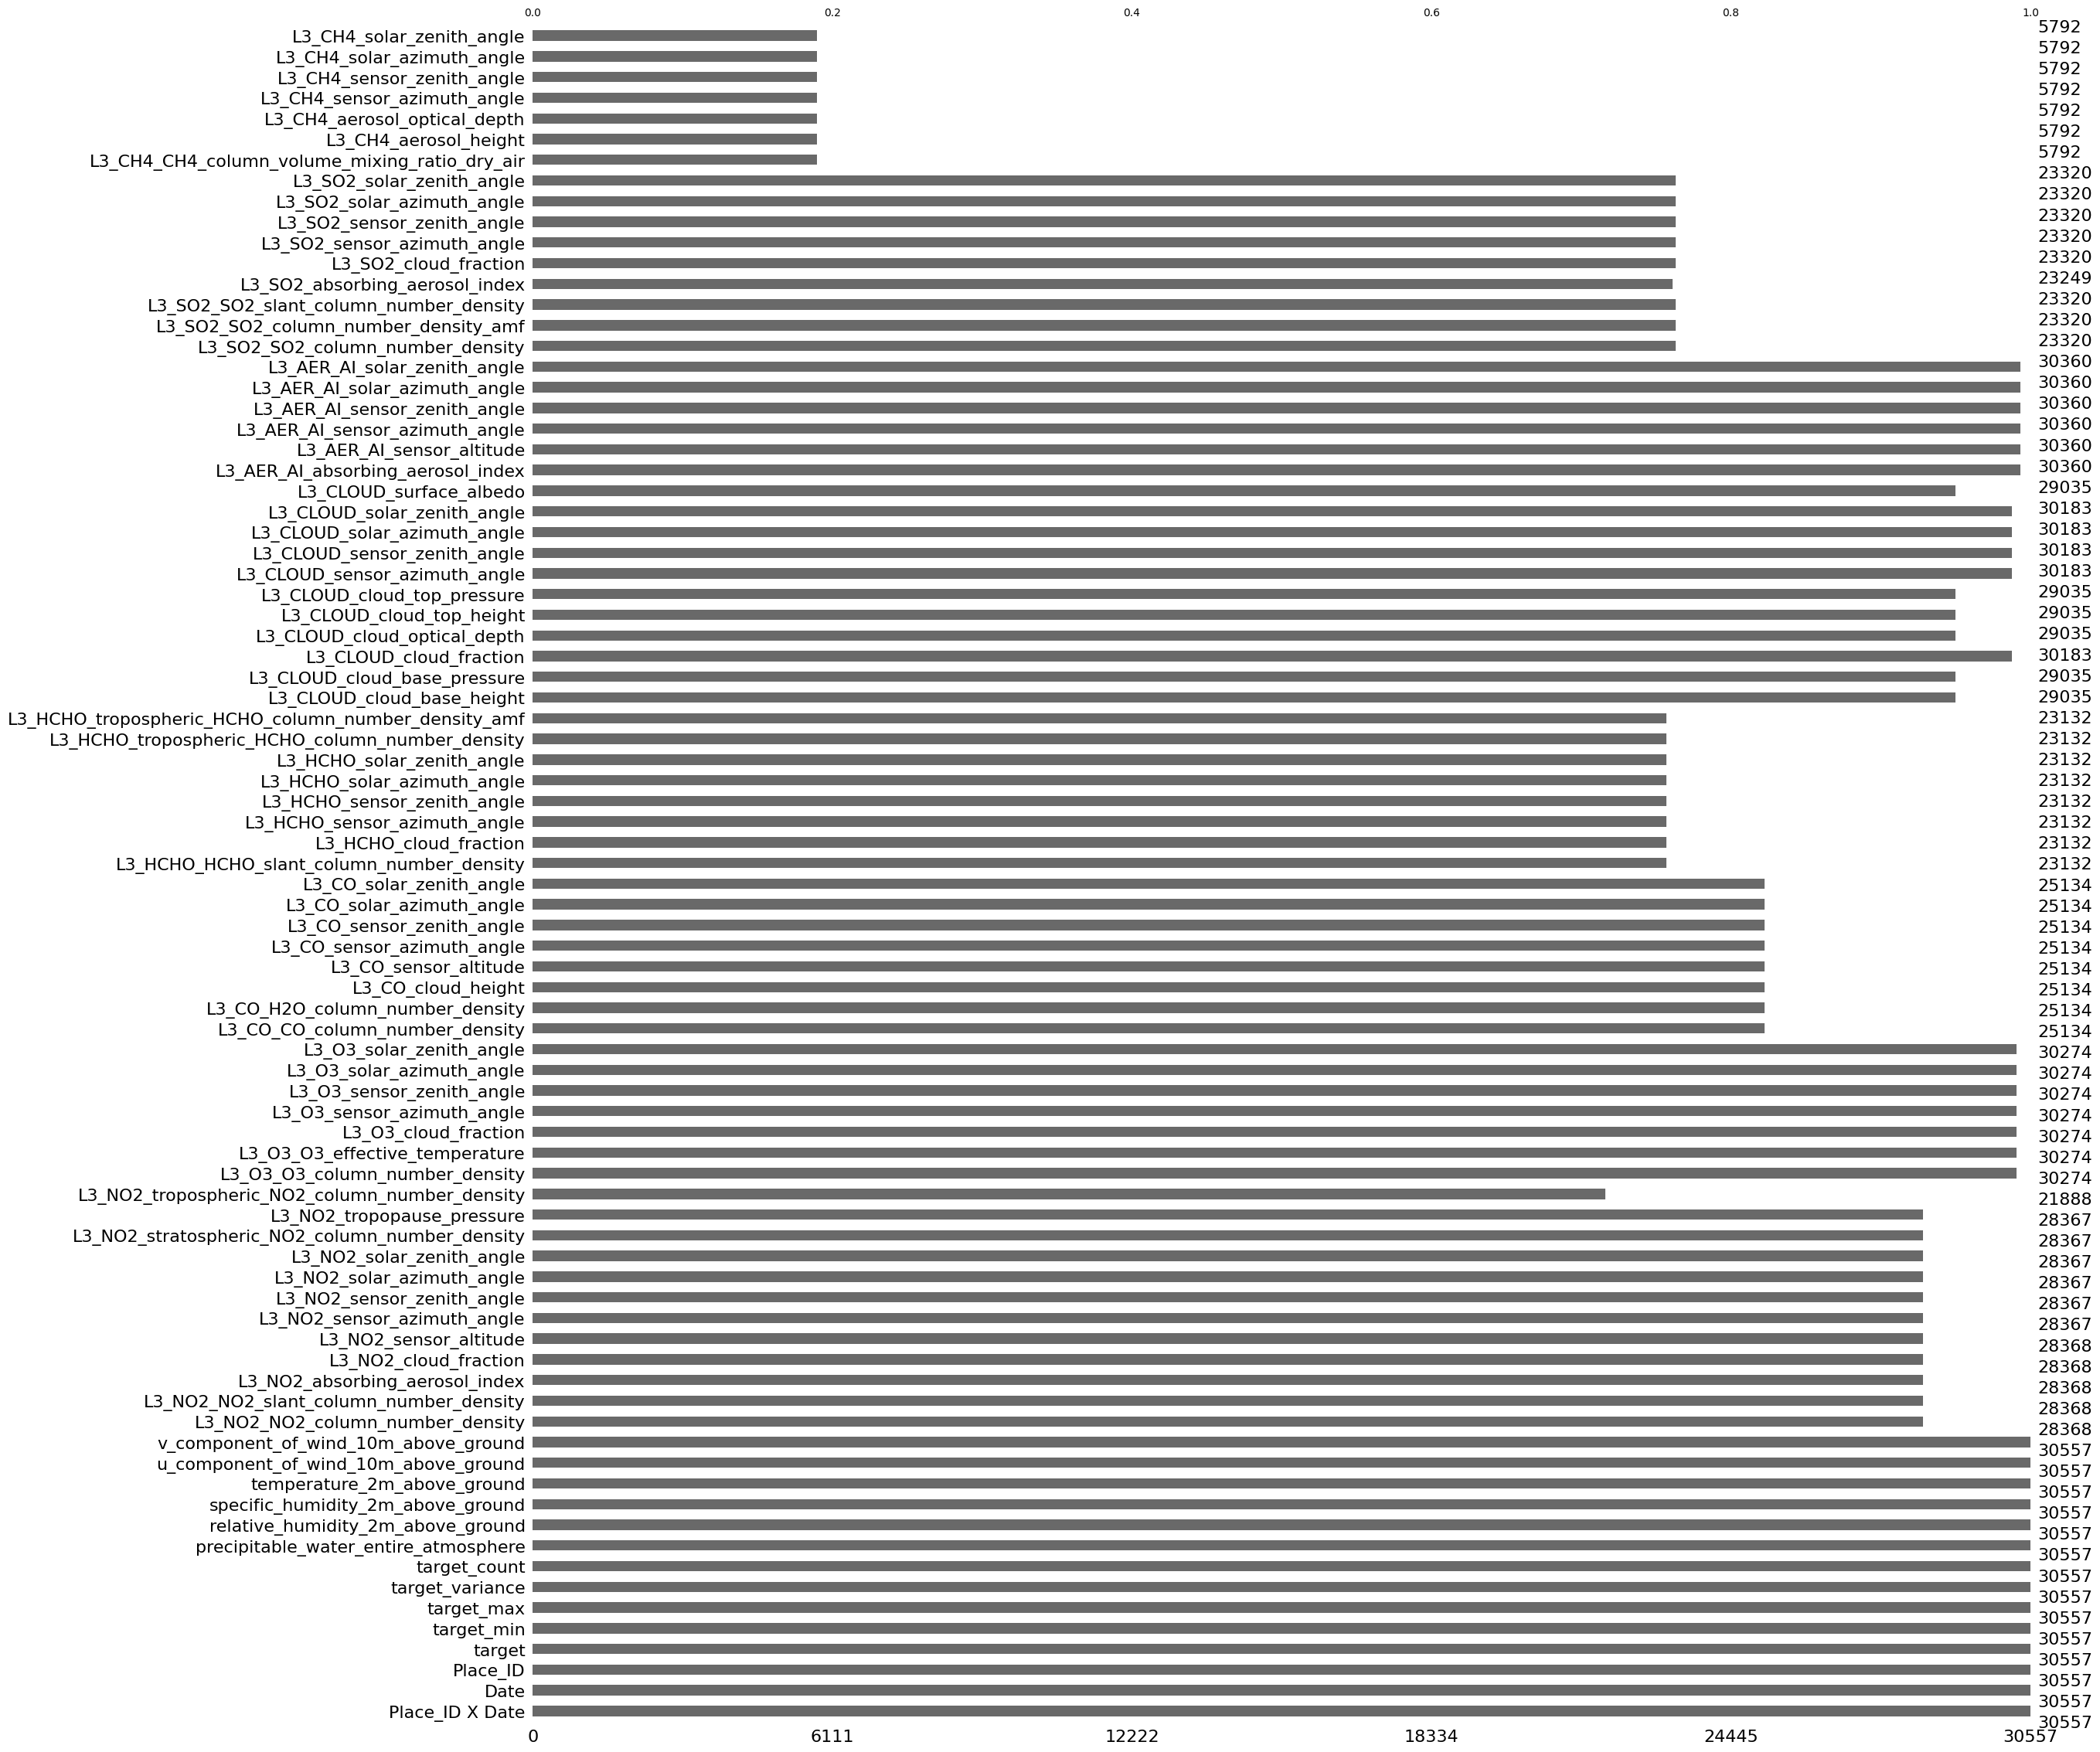

In [12]:
msno.bar(df)

In [13]:
df.describe()



,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,u_component_of_wind_10m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
count,30557.000000,30557.000000,30557.000000,3.055700e+04,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,...,23320.000000,23320.000000,23320.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000,5792.000000
mean,61.148045,29.025866,117.992234,7.983756e+03,125.831135,15.302326,70.552747,0.006004,9.321342,0.416886,...,35.590916,-123.697777,46.533951,923.231949,1711.793613,0.016227,1.254703,13.849040,-69.098594,23.100630
std,46.861309,33.119775,100.417713,4.863090e+04,146.581856,10.688573,18.807884,0.003787,9.343226,2.707990,...,18.955228,71.916036,14.594267,929.633988,1741.299304,0.027016,55.101250,18.004375,84.702355,24.786350
min,1.000000,1.000000,1.000000,0.000000e+00,2.000000,0.420044,5.128572,0.000139,-34.647879,-15.559646,...,0.000000,-179.880630,0.000000,0.000000,0.000000,0.000000,-105.367363,0.000000,-179.947422,0.000000
25%,25.000000,5.000000,60.000000,1.064920e+03,44.000000,7.666667,58.600002,0.003403,3.123071,-1.097864,...,19.451524,-165.882624,36.693094,0.000000,0.000000,0.000000,0.000000,0.000000,-161.726937,0.000000
50%,50.000000,15.000000,91.000000,2.395350e+03,72.000000,12.200000,74.099998,0.004912,8.478424,0.222092,...,37.918838,-156.637162,47.445010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,80.000000,44.000000,155.000000,5.882550e+03,150.000000,19.900000,85.450001,0.007562,16.201563,1.772925,...,52.270055,-118.453598,57.438181,1861.674119,3393.541633,0.023829,62.245728,27.412303,0.000000,47.090635
max,815.000000,438.000000,999.000000,1.841490e+06,1552.000000,72.599998,100.000000,0.021615,37.437921,17.955124,...,66.111289,179.776125,79.631711,2112.522949,6478.550544,0.210483,77.355232,59.972710,179.813344,69.992363


In [14]:
df_filtered = df.loc[:, ~((df.columns.str.startswith('L3')) & (~df.columns.str.contains('column_number_density')))]

In [15]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 27 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

In [16]:
type(df['Date'])
#->Change to np datetime

pandas.core.series.Series

In [17]:
def filter_cols(df):

    keep_cols = ['L3_CLOUD_cloud_fraction', 
                 'L3_CLOUD_cloud_base_height', 
                 'L3_CLOUD_cloud_optical_depth', 
                 'L3_AER_AI_absorbing_aerosol_index']

    mask = (
        (df.columns.str.startswith('L3')) & 
        (~df.columns.str.contains('column_number_density')) |
        df.columns.str.contains('slant|stratospheric|amf'))

    return df.loc[:, ~mask | df.columns.isin(keep_cols)]


In [18]:
df_filtered = filter_cols(df)

In [19]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 25 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Place_ID X Date                                  30557 non-null  object 
 1   Date                                             30557 non-null  object 
 2   Place_ID                                         30557 non-null  object 
 3   target                                           30557 non-null  float64
 4   target_min                                       30557 non-null  float64
 5   target_max                                       30557 non-null  float64
 6   target_variance                                  30557 non-null  float64
 7   target_count                                     30557 non-null  int64  
 8   precipitable_water_entire_atmosphere             30557 non-null  float64
 9   relative_humidity_2m_above_g

In [20]:
sns.pairplot(df_filtered,hue='target')

KeyboardInterrupt: 

: 

: 

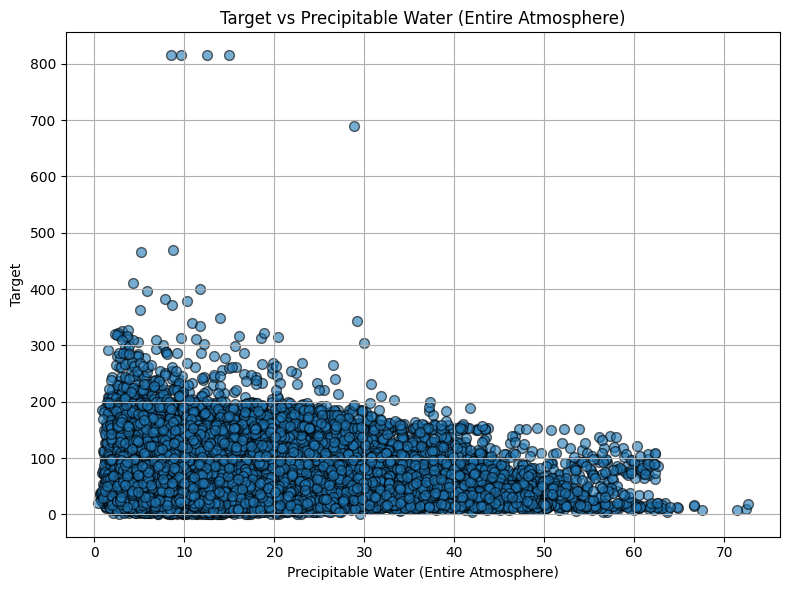

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["precipitable_water_entire_atmosphere"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("Precipitable Water (Entire Atmosphere)")
plt.ylabel("Target")
plt.title("Target vs Precipitable Water (Entire Atmosphere)")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

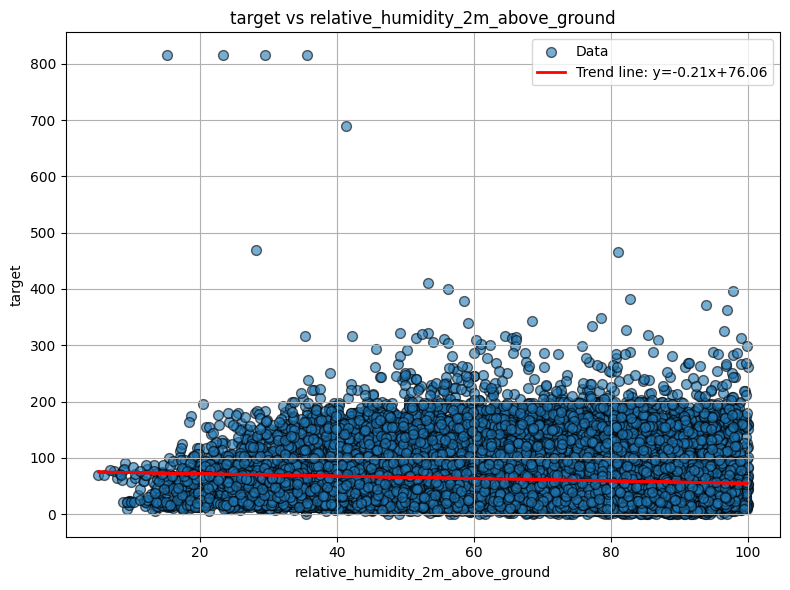

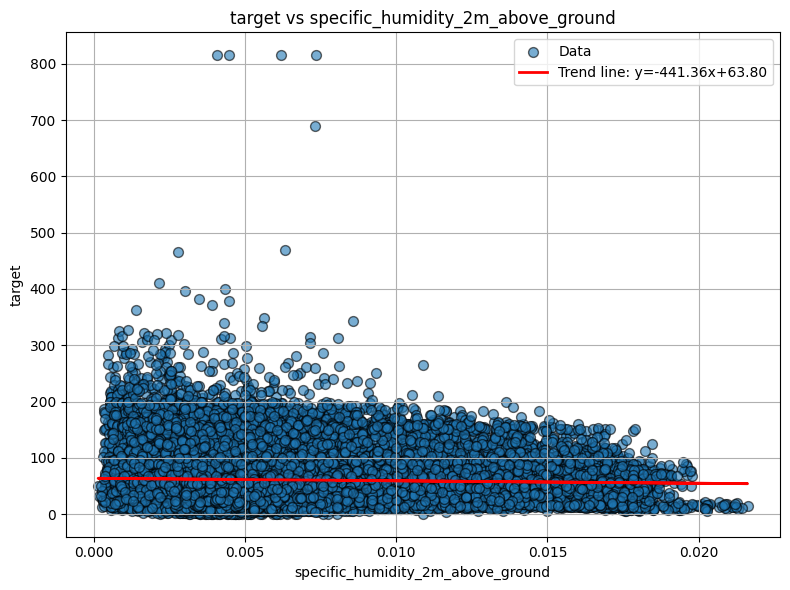

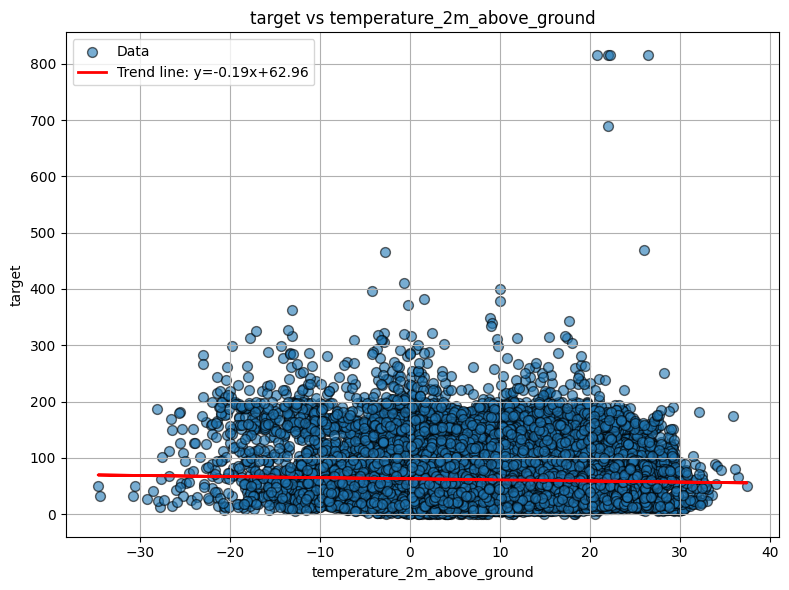

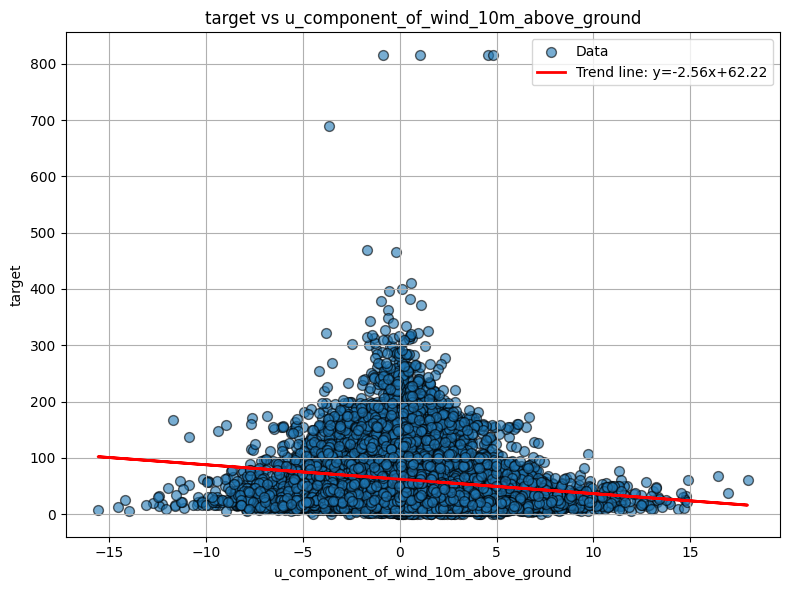

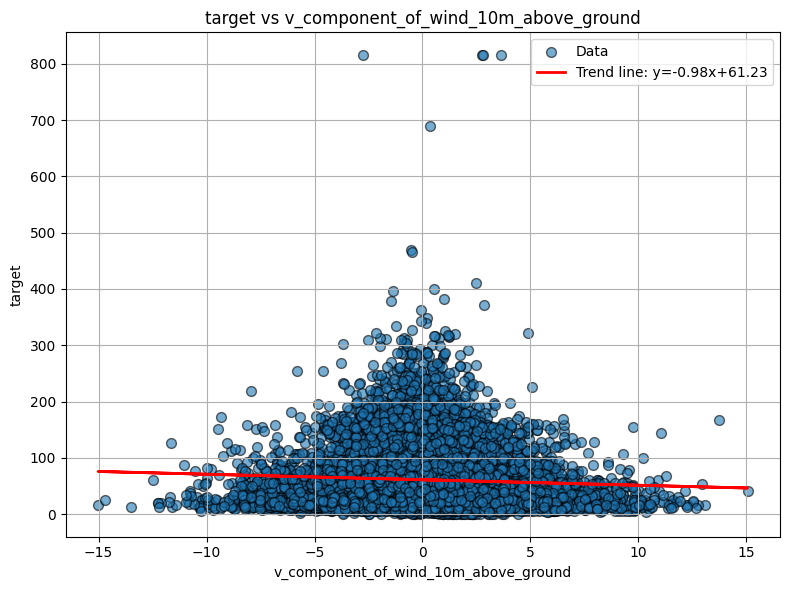

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


LinAlgError: SVD did not converge in Linear Least Squares

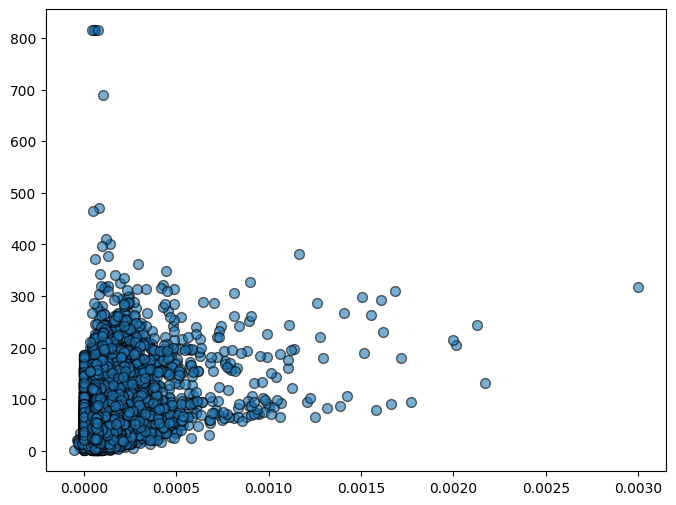

In [ ]:

def scatter_plots_with_trend(df, target_col, start_idx, end_idx):
    """
    Creates scatter plots of target_col vs columns from start_idx to end_idx,
    with a linear regression trend line.
    
    Parameters:
        df (pd.DataFrame): Your DataFrame
        target_col (str): Name of the target column
        start_idx (int): Starting column index (inclusive)
        end_idx (int): Ending column index (inclusive)
    """
    for col in df.columns[start_idx:end_idx + 1]:
        x = df[col]
        y = df[target_col]
        
        plt.figure(figsize=(8,6))
        plt.scatter(x, y, alpha=0.6, edgecolor='k', s=50, label='Data')
        
        # Fit linear regression line
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m*x + b, color='red', linewidth=2, label=f'Trend line: y={m:.2f}x+{b:.2f}')
        
        plt.xlabel(col)
        plt.ylabel(target_col)
        plt.title(f"{target_col} vs {col}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Example usage:
scatter_plots_with_trend(df_filtered, target_col="target", start_idx=9, end_idx=25)

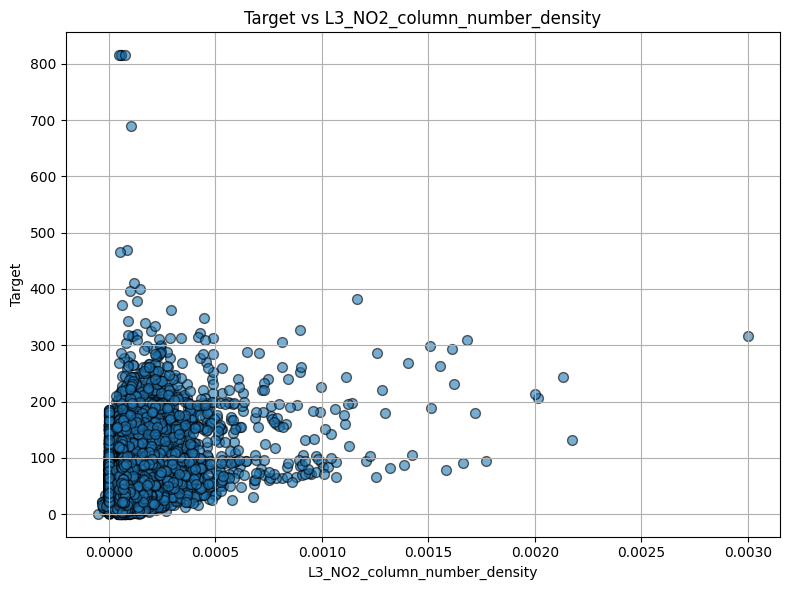

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_NO2_NO2_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_NO2_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_NO2_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

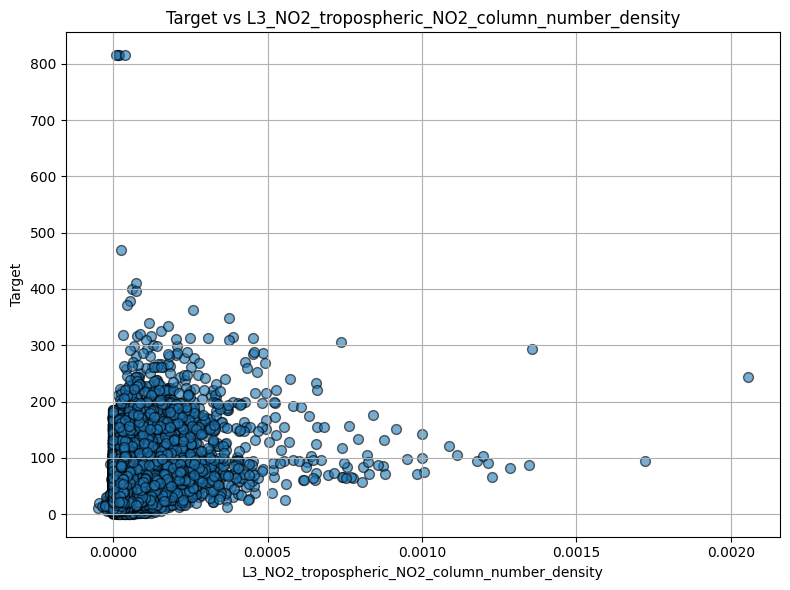

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_NO2_tropospheric_NO2_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_NO2_tropospheric_NO2_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_NO2_tropospheric_NO2_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

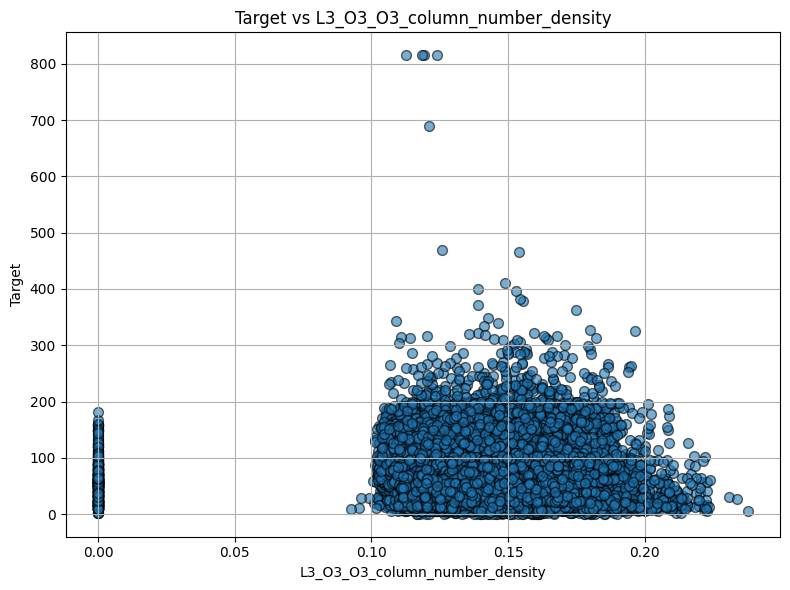

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_O3_O3_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_O3_O3_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_O3_O3_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

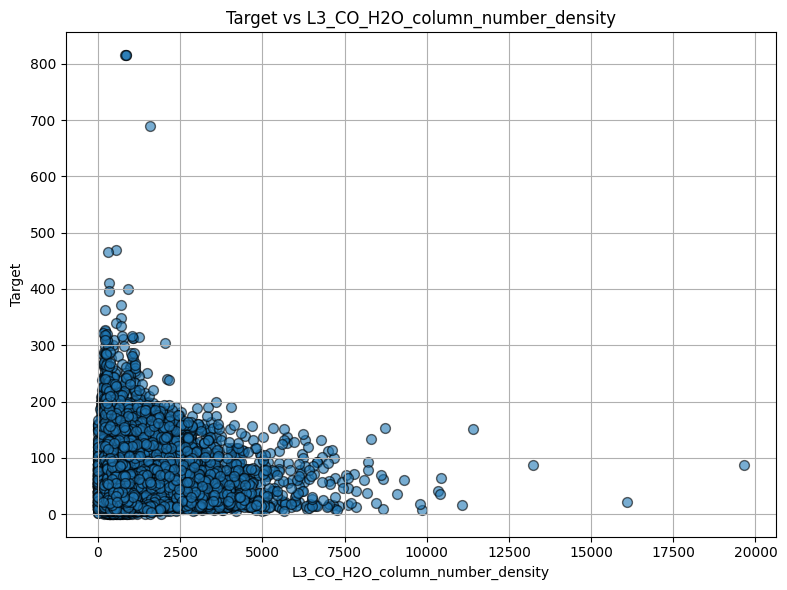

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_CO_H2O_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_CO_H2O_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_CO_H2O_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

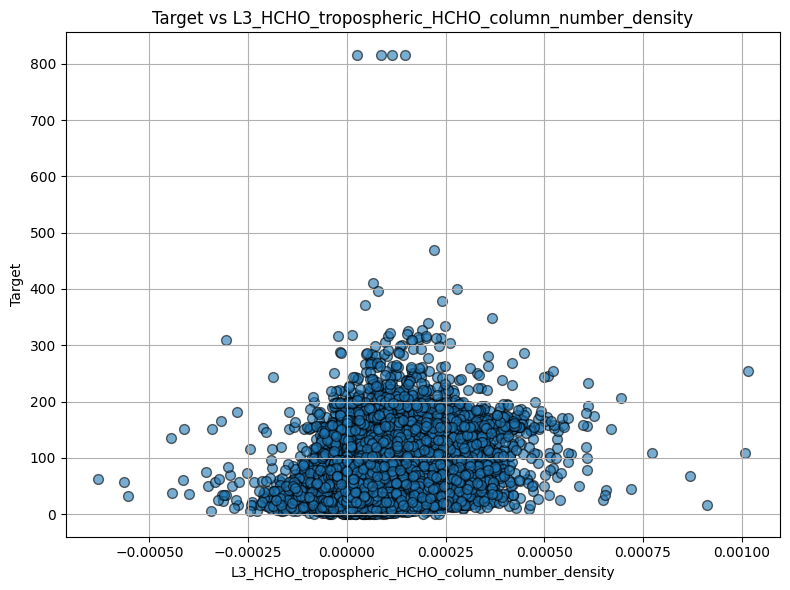

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_HCHO_tropospheric_HCHO_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_HCHO_tropospheric_HCHO_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_HCHO_tropospheric_HCHO_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

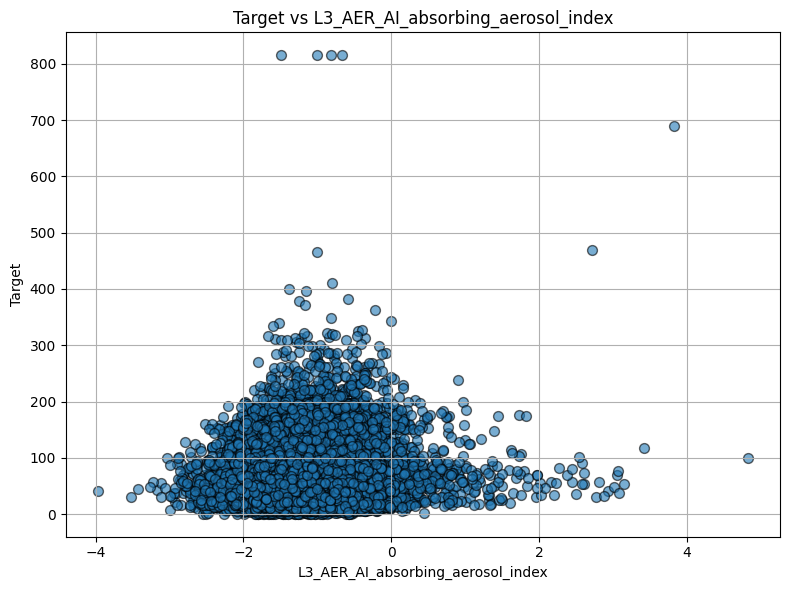

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_AER_AI_absorbing_aerosol_index"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_AER_AI_absorbing_aerosol_index")
plt.ylabel("Target")
plt.title("Target vs L3_AER_AI_absorbing_aerosol_index")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

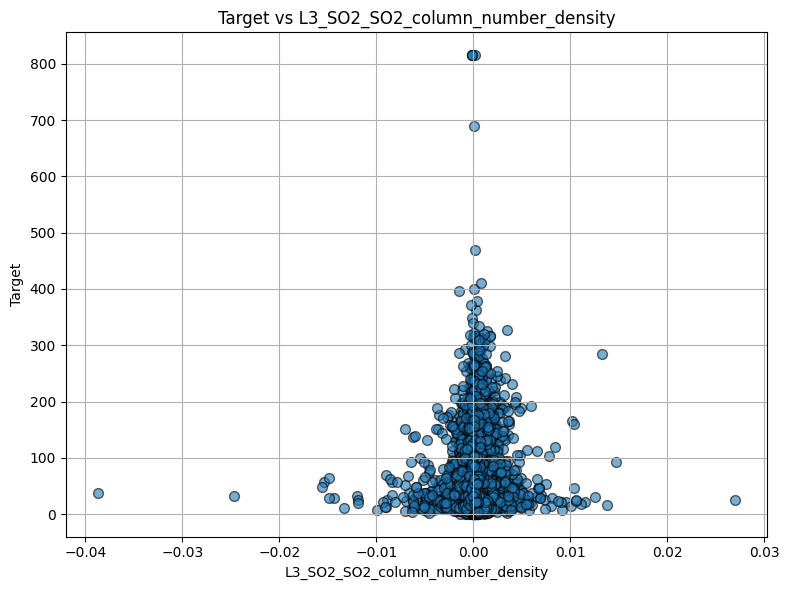

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_SO2_SO2_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_SO2_SO2_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_SO2_SO2_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

In [ ]:
#-> remove outliers below 

In [ ]:
plt.figure(figsize=(8,6))  

plt.scatter(
    df_filtered["L3_NO2_NO2_column_number_density"],
    df_filtered["target"],
    alpha=0.6,  # make points slightly transparent for dense data
    edgecolor='k', # black edge around points
    s=50          # size of points
)

plt.xlabel("L3_NO2_NO2_column_number_density")
plt.ylabel("Target")
plt.title("Target vs L3_NO2_NO2_column_number_density")
plt.grid(True)  # add grid for readability
plt.tight_layout()  # better layout
plt.show()

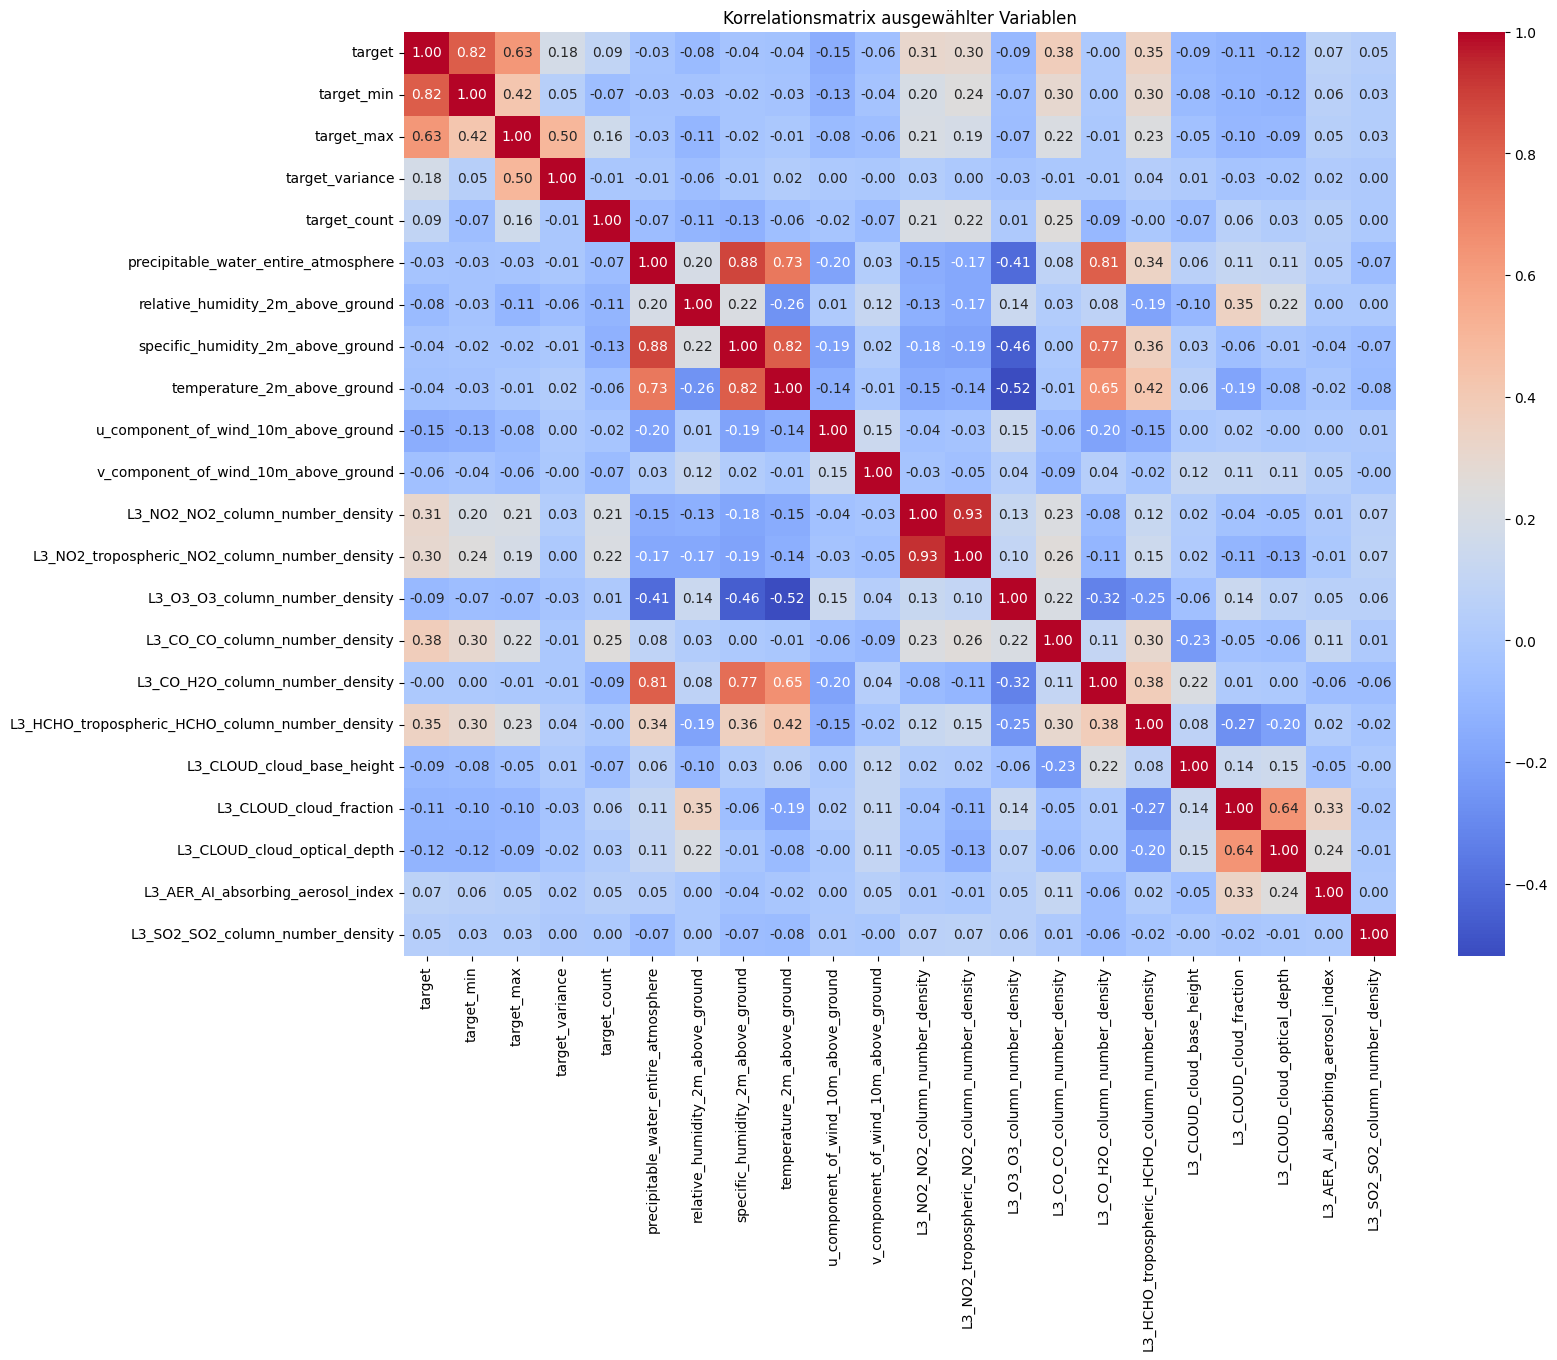

In [ ]:
# Plot correlation matrix   
corr = df_filtered.corr(numeric_only=True)
plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korrelationsmatrix ausgewählter Variablen")
plt.show()

# Data Cleaning

In [5]:
from clean_fct import filter_cols


In [6]:
df_filtered = filter_cols(df)

In [7]:
#Duplicates check

df_filtered.duplicated().value_counts()

False    30557
Name: count, dtype: int64

In [8]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")


### Detect Skewness and distribution
.describe()
(Boxplot)

In [ ]:
df_filtered.describe()

,Date,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,...,L3_NO2_tropospheric_NO2_column_number_density,L3_O3_O3_column_number_density,L3_CO_CO_column_number_density,L3_CO_H2O_column_number_density,L3_HCHO_tropospheric_HCHO_column_number_density,L3_CLOUD_cloud_base_height,L3_CLOUD_cloud_fraction,L3_CLOUD_cloud_optical_depth,L3_AER_AI_absorbing_aerosol_index,L3_SO2_SO2_column_number_density
count,30557,30557.000000,30557.000000,30557.000000,3.055700e+04,30557.000000,30557.000000,30557.000000,30557.000000,30557.000000,...,21888.000000,30274.000000,25134.000000,25134.000000,23132.000000,29035.000000,30183.000000,29035.000000,30360.000000,23320.000000
mean,2020-02-17 11:32:35.807180032,61.148045,29.025866,117.992234,7.983756e+03,125.831135,15.302326,70.552747,0.006004,9.321342,...,0.000056,0.139533,0.036230,983.448217,0.000088,2510.989311,0.433513,18.201564,-1.161213,0.000113
min,2020-01-02 00:00:00,1.000000,1.000000,1.000000,0.000000e+00,2.000000,0.420044,5.128572,0.000139,-34.647879,...,-0.000049,0.000000,0.000000,0.000000,-0.000630,8.997803,0.000000,1.000000,-3.967332,-0.038756
25%,2020-01-25 00:00:00,25.000000,5.000000,60.000000,1.064920e+03,44.000000,7.666667,58.600002,0.003403,3.123071,...,0.000016,0.121587,0.031181,414.197452,0.000028,771.406343,0.112687,5.195713,-1.517307,-0.000107
50%,2020-02-17 00:00:00,50.000000,15.000000,91.000000,2.395350e+03,72.000000,12.200000,74.099998,0.004912,8.478424,...,0.000035,0.140809,0.035563,713.649325,0.000076,1855.512628,0.340757,8.520578,-1.179243,0.000056
75%,2020-03-12 00:00:00,80.000000,44.000000,155.000000,5.882550e+03,150.000000,19.900000,85.450001,0.007562,16.201563,...,0.000070,0.157940,0.039797,1241.946035,0.000134,3667.166162,0.771836,21.040006,-0.817034,0.000280
max,2020-04-04 00:00:00,815.000000,438.000000,999.000000,1.841490e+06,1552.000000,72.599998,100.000000,0.021615,37.437921,...,0.002055,0.237652,0.291536,19656.359702,0.001015,14000.000000,1.000000,237.121177,4.824804,0.026994
std,NaN,46.861309,33.119775,100.417713,4.863090e+04,146.581856,10.688573,18.807884,0.003787,9.343226,...,0.000075,0.030511,0.010909,906.694162,0.000094,2244.918638,0.350953,23.790555,0.538363,0.000899


In [10]:
skew_values = df_filtered.skew(numeric_only=True).sort_values(ascending=False)

# Display skewed features
print("Skewness of numerical features:")
print(skew_values)

Skewness of numerical features:
target_variance                                    23.455691
L3_NO2_NO2_column_number_density                    7.402073
L3_NO2_tropospheric_NO2_column_number_density       6.185637
target_max                                          3.915403
target_count                                        3.706539
L3_CLOUD_cloud_optical_depth                        3.346628
L3_CO_H2O_column_number_density                     3.266800
target                                              2.043157
target_min                                          1.931902
precipitable_water_entire_atmosphere                1.428406
L3_CLOUD_cloud_base_height                          1.318588
L3_CO_CO_column_number_density                      1.274629
specific_humidity_2m_above_ground                   1.245273
L3_HCHO_tropospheric_HCHO_column_number_density     0.905838
L3_AER_AI_absorbing_aerosol_index                   0.703341
u_component_of_wind_10m_above_ground                0

In [11]:
# List of columns to exclude from skewness handling
target_related_cols = ['target', 'target_variance', 'target_min', 'target_max', 'target_count']

# Highlight highly skewed features excluding target-related columns
skewed_cols_excluding_target = skew_values[abs(skew_values) > 2].drop(labels=target_related_cols, errors='ignore')

print("Highly skewed columns (excluding target-related):")
print(skewed_cols_excluding_target)


Highly skewed columns (excluding target-related):
L3_NO2_NO2_column_number_density                 7.402073
L3_NO2_tropospheric_NO2_column_number_density    6.185637
L3_CLOUD_cloud_optical_depth                     3.346628
L3_CO_H2O_column_number_density                  3.266800
L3_SO2_SO2_column_number_density                -3.644402
dtype: float64


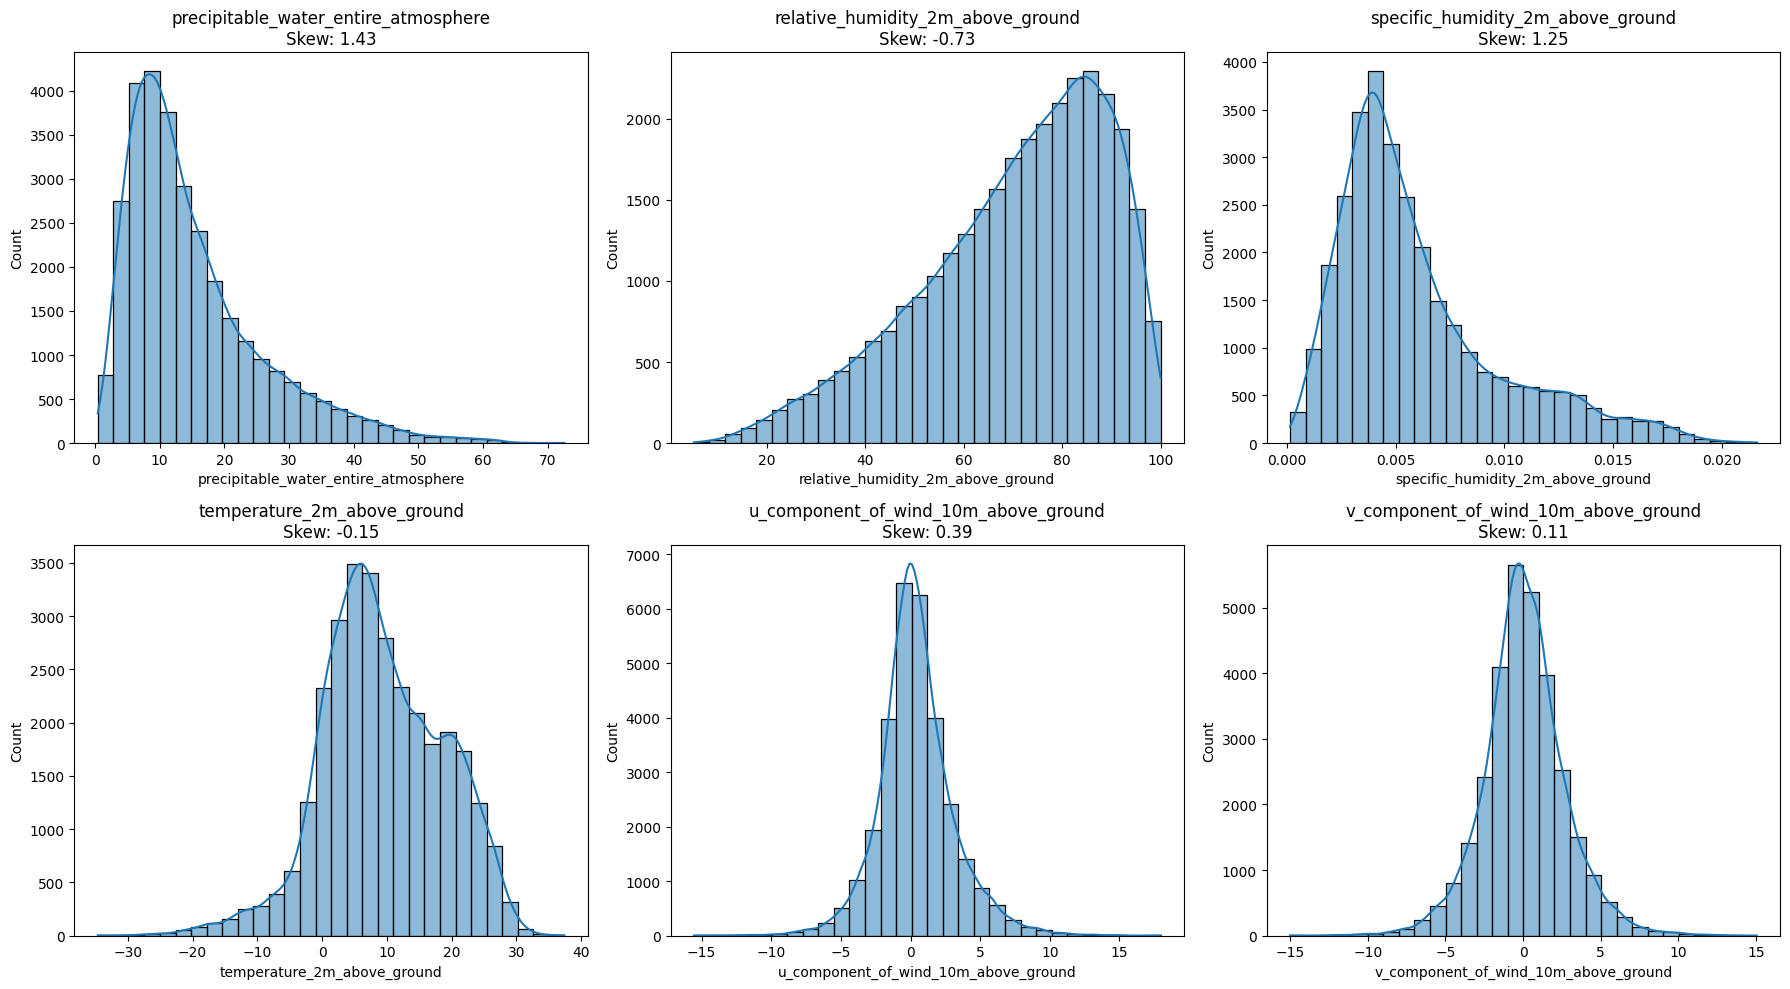

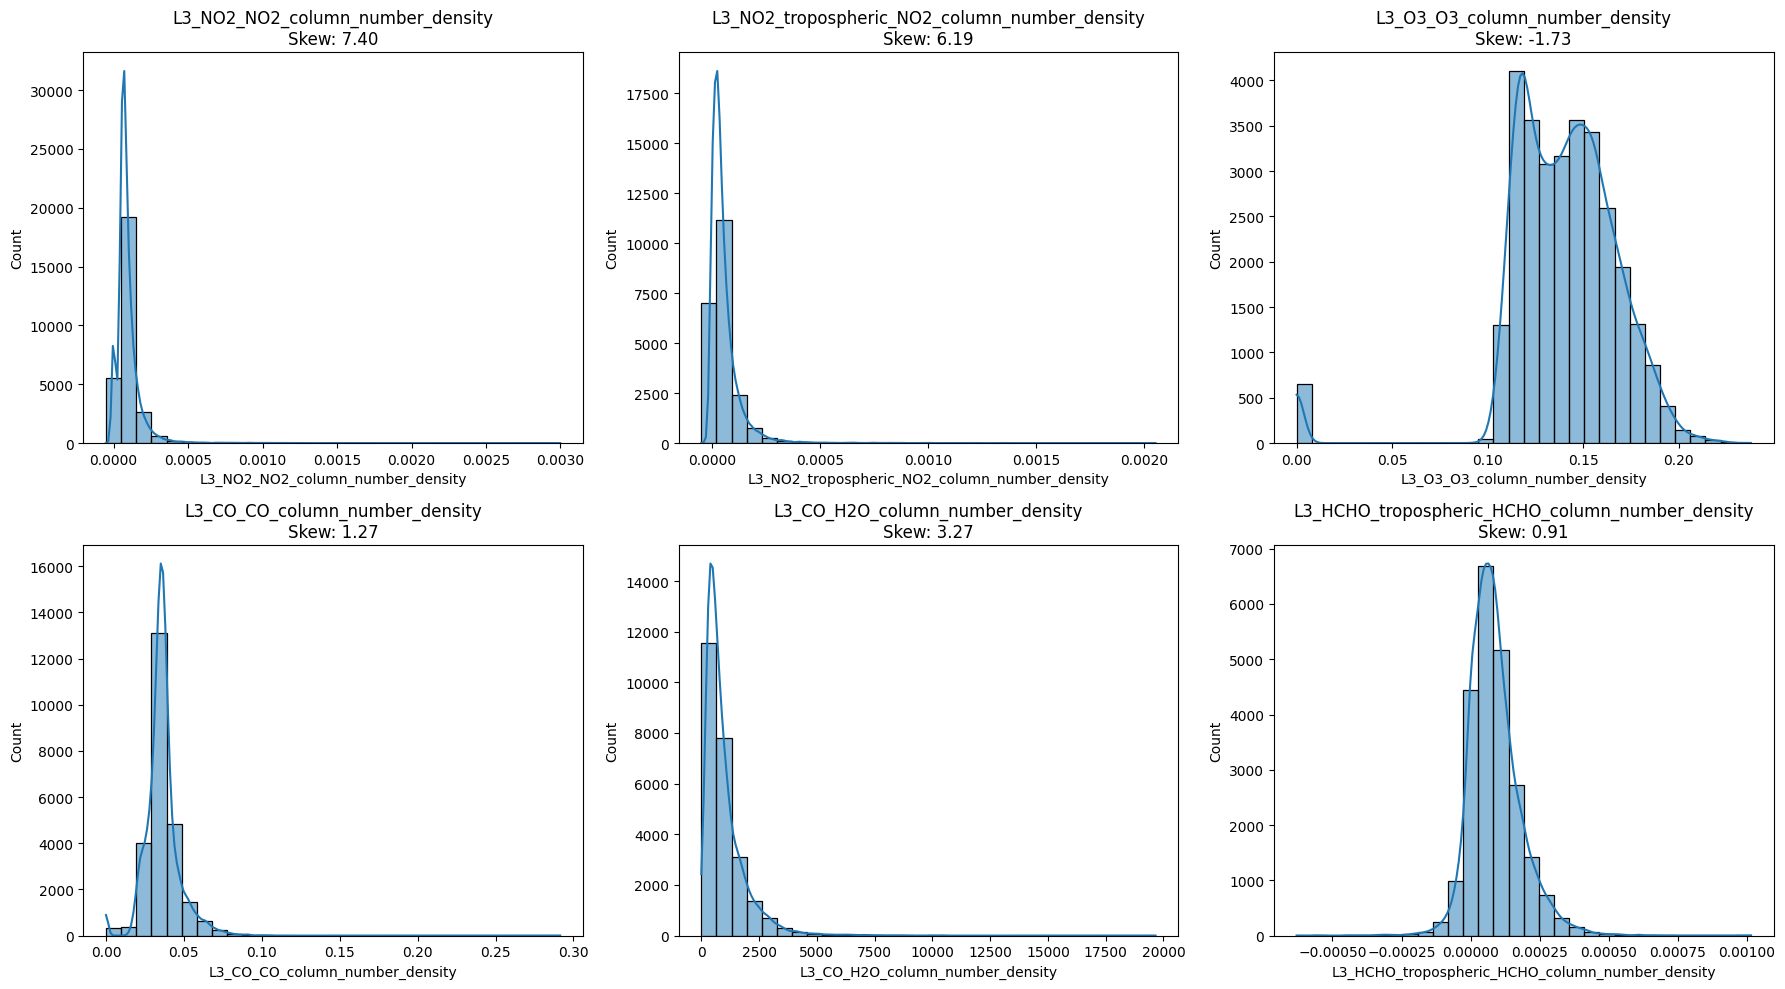

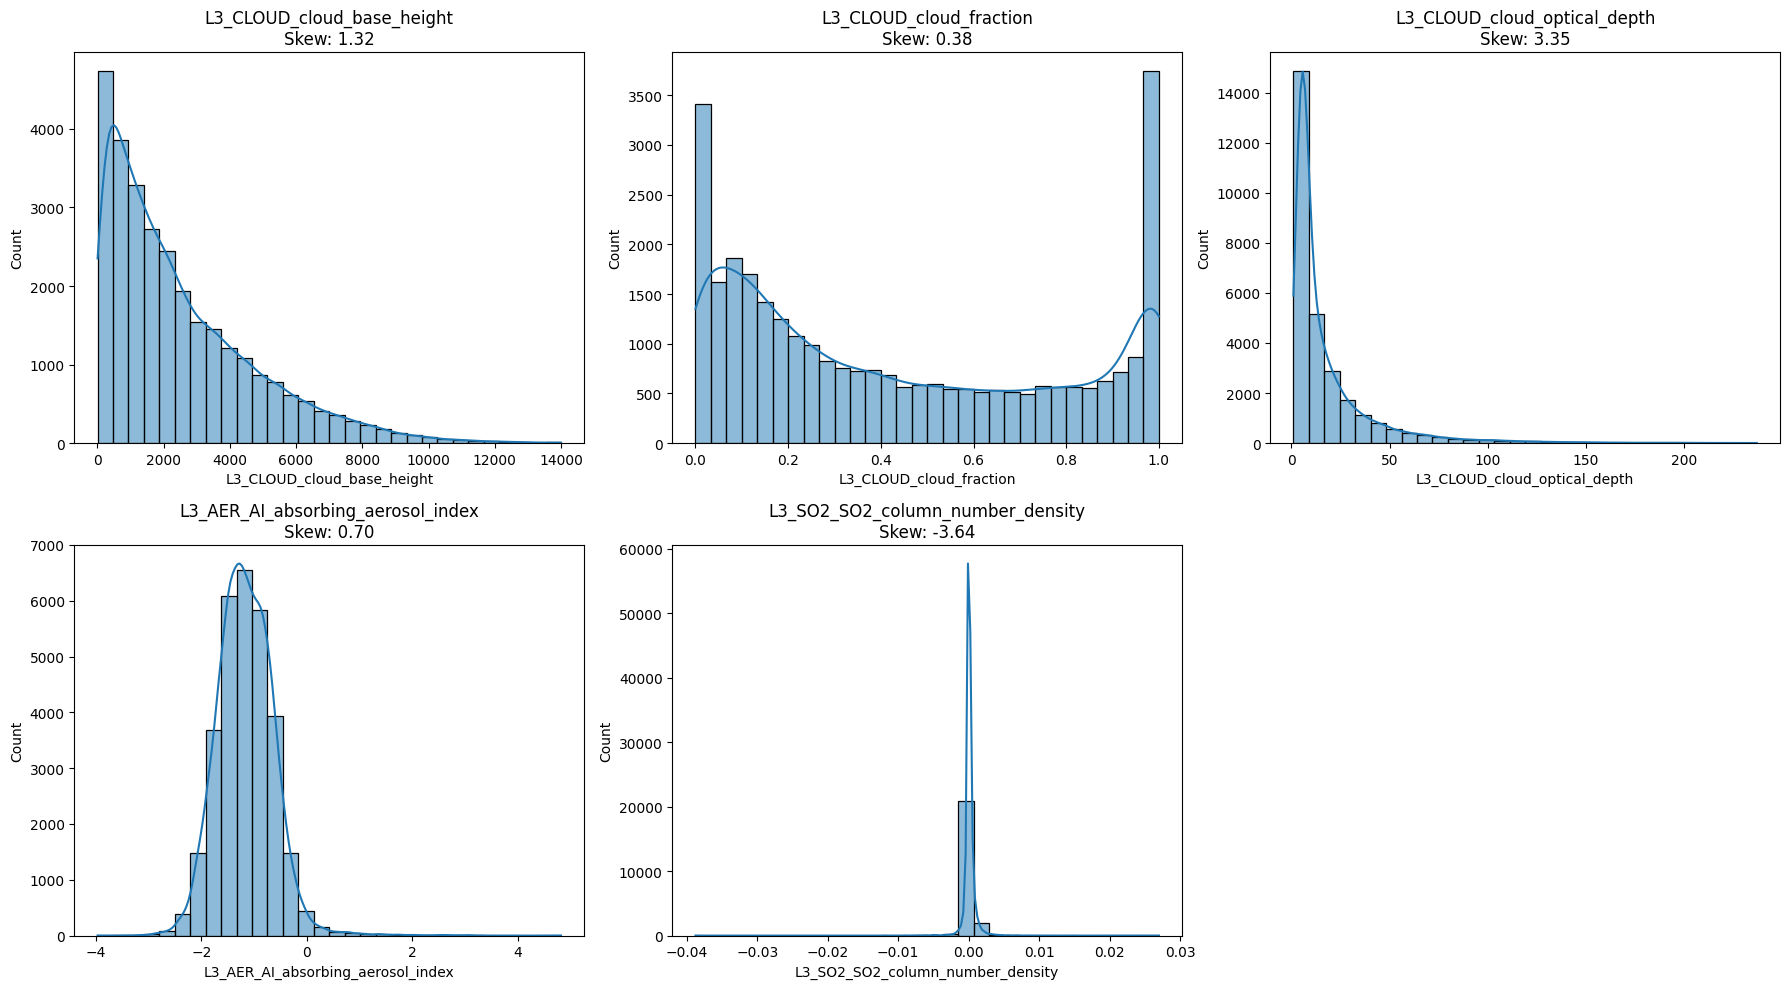

In [ ]:
# List of columns to exclude
target_related_cols = ['target', 'target_variance', 'target_min', 'target_max', 'target_count']

# Numeric columns excluding target-related
numeric_cols = [col for col in df_filtered.select_dtypes(include=np.number).columns if col not in target_related_cols]

# Plot 6 histograms per figure
cols_per_fig = 6
n_figs = math.ceil(len(numeric_cols) / cols_per_fig)

for i in range(n_figs):
    subset = numeric_cols[i*cols_per_fig:(i+1)*cols_per_fig]
    plt.figure(figsize=(18, 10))
    for j, col in enumerate(subset, 1):
        plt.subplot(2, 3, j)
        sns.histplot(df_filtered[col].dropna(), kde=True, bins=30)
        plt.title(f"{col}\nSkew: {df_filtered[col].skew():.2f}")
    plt.tight_layout()
    plt.show()



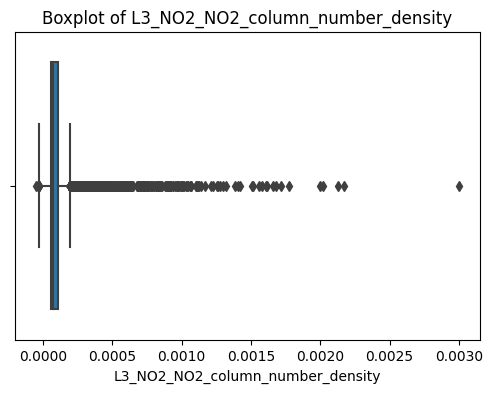

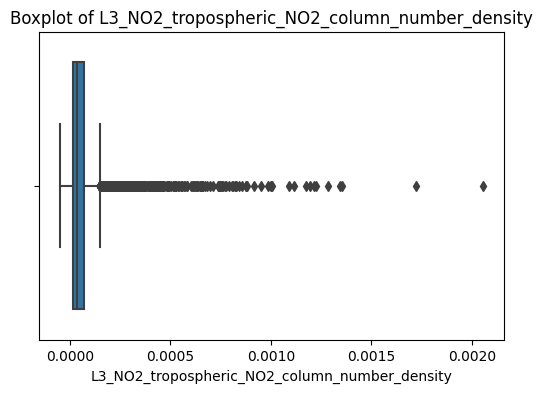

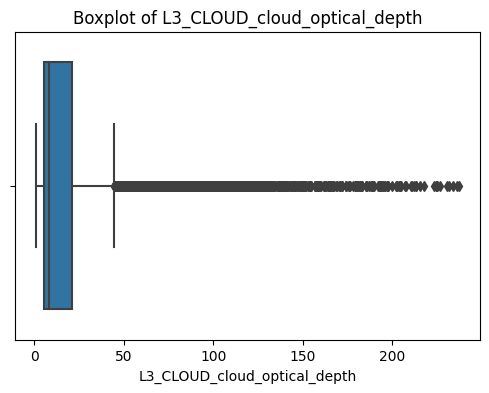

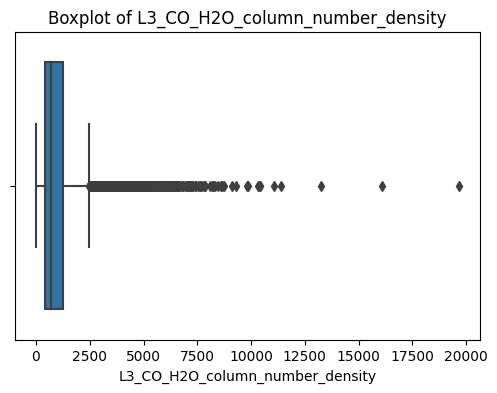

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Original skewed features
skewed_features = [
    'target_variance', 
    'L3_NO2_NO2_column_number_density', 
    'L3_NO2_tropospheric_NO2_column_number_density', 
    'target_max', 
    'target_count', 
    'L3_CLOUD_cloud_optical_depth', 
    'L3_CO_H2O_column_number_density'
]

# List of target-related columns to exclude
target_related_cols = ['target', 'target_variance', 'target_min', 'target_max', 'target_count']

# Keep only features, remove target-derived
skewed_features_filtered = [col for col in skewed_features if col not in target_related_cols]

# Plot boxplots
for col in skewed_features_filtered:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_filtered[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


### Check and remove Outliers

Assessing outliers/ extreme values so we are able to see which and how to handle them.

In [12]:
# List of target-related columns to exclude
target_related_cols = ['target', 'target_variance', 'target_min', 'target_max', 'target_count']

# Only keep skewed predictor features
skewed_features_filtered = [col for col in skewed_features if col not in target_related_cols]

# Function to detect outliers using IQR
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Check outliers for predictor features
for col in skewed_features_filtered:
    outliers = detect_outliers(df_filtered, col)
    print(f"{col} → {len(outliers)} outliers")



NameError: name 'skewed_features' is not defined

## Preprocessing

Creating a pipeline to process numeric columns (excluding target variables) that respects physical constraints and handles outliers and skewness. M=

In [13]:
from clean_fct import filter_cols
from sklearn.preprocessing import PowerTransformer, StandardScaler


def preprocess_for_air_quality(
    df: pd.DataFrame,
    date_col: str = "Date",
    place_col: str = "Place_ID",
    target_col: str = "target",
    impute_method: str = "weekly",
    scale: bool = True
) -> pd.DataFrame:
    """
    Preprocess predictor columns for the Air Pollution Challenge.
    
    Steps:
    1) Time-aware imputation of missing numeric predictor values
    2) Remove impossible vertical column values (< -0.001 mol/m²)
    3) Cap extremely high cloud values (99th percentile)
    4) Winsorize extreme values (1st-99th percentile)
    5) Transform highly skewed features
    6) Optional scaling
    Target and target-derived columns are untouched.
    """

    from copy import deepcopy
    df_proc = deepcopy(df)

    # Identify numeric columns excluding target and target-related
    target_related_cols = [target_col, 'target_min', 'target_max', 'target_variance', 'target_count']
    numeric_cols = [c for c in df_proc.select_dtypes(include=np.number).columns if c not in target_related_cols]

    # 1) Impute missing values using the time-aware function
    df_proc = impute_numeric_by_time(df_proc, date_col=date_col, place_col=place_col, method=impute_method)

    # 2) Remove impossible negative vertical column densities
    for col in numeric_cols:
        if "column" in col or col.endswith("_density"):
            df_proc = df_proc[df_proc[col] >= -0.001]

    # 3) Cap extremely high cloud values at 99th percentile
    cloud_cols = [c for c in numeric_cols if "cloud" in c.lower()]
    for col in cloud_cols:
        upper_limit = df_proc[col].quantile(0.99)
        df_proc[col] = df_proc[col].clip(lower=None, upper=upper_limit)

    # 4) Winsorize all numeric columns (1st-99th percentile)
    def cap_outliers(series, lower_quantile=0.01, upper_quantile=0.99):
        lower = series.quantile(lower_quantile)
        upper = series.quantile(upper_quantile)
        return series.clip(lower, upper)

    for col in numeric_cols:
        df_proc[col] = cap_outliers(df_proc[col])

    # 5) Transform highly skewed features (>2)
    skewed_features = df_proc[numeric_cols].skew().sort_values(ascending=False)
    high_skew = skewed_features[abs(skewed_features) > 2].index.tolist()
    if high_skew:
        pt = PowerTransformer(method='yeo-johnson')
        df_proc[high_skew] = pt.fit_transform(df_proc[high_skew])

    # 6) Optional scaling
    if scale:
        scaler = StandardScaler()
        df_proc[numeric_cols] = scaler.fit_transform(df_proc[numeric_cols])

    return df_proc


In [14]:
from impute_by_date import impute_numeric_by_time
# Step 0: Filter only the columns you want
df_filtered = filter_cols(df)  # your filtered training data

# Step 1: Preprocess predictor columns
df_processed = preprocess_for_air_quality(df_filtered, impute_method="weekly")

# Inspect processed data
print(df_processed.info())

df_processed.to_csv("data/df_processed.csv")


<class 'pandas.core.frame.DataFrame'>
Index: 28753 entries, 0 to 30556
Data columns (total 25 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Place_ID X Date                                  28753 non-null  object        
 1   Date                                             28753 non-null  datetime64[ns]
 2   Place_ID                                         28753 non-null  object        
 3   target                                           28753 non-null  float64       
 4   target_min                                       28753 non-null  float64       
 5   target_max                                       28753 non-null  float64       
 6   target_variance                                  28753 non-null  float64       
 7   target_count                                     28753 non-null  int64         
 8   precipitable_water_entire_atmosphere     